# Top tagging 

This notebook is dedicated to exploring the dataset and visualizing the features to gain insights into the data distribution and relationships between variables. We will use various plotting techniques to understand the characteristics of the dataset and identify any patterns or anomalies that may be present. 

The 3 main datasets wil be:
- **Top tagging**: This dataset contains information about top quark tagging, which is a technique used in particle physics to identify top quarks in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for top quark identification.
- **Quark-gluon jet tagging**: This dataset contains information about quark-gluon jet tagging, which is a technique used to distinguish between jets originating from quarks and gluons. The features in this dataset may include various jet substructure observables and kinematic variables that are relevant for quark-gluon discrimination.
- **Higgs tagging**: This dataset contains information about Higgs boson tagging, which is a technique used to identify Higgs bosons in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for Higgs boson identification.

We can find the dataset in the following path: `../data/val.h5`. We use the val test to not load 1 GB from train set. We will load the dataset and perform some exploratory data analysis to understand the distribution of the features and the relationships between them. We will start by loading the dataset and displaying some basic information about it, such as the number of samples, the number of features, and the distribution of the target variable. We will then create various plots to visualize the data, such as histograms, scatter plots, and correlation matrices. This will help us identify any patterns or anomalies in the data that may be relevant for our analysis.

**Description taken from the original source:** [zenodo](https://zenodo.org/records/2603256)

A set of MC simulated training/testing events for the evaluation of top quark tagging architectures.

In total 1.2M training events, 400k validation events and 400k test events. Use “train” for training, “val” for validation during the training and “test” for final testing and reporting results.

Description

- 14 TeV, hadronic tops for signal, qcd diets background, Delphes ATLAS detector card with Pythia8

- No MPI/pile-up included

- Clustering of  particle-flow entries (produced by Delphes E-flow) into anti-kT 0.8 jets in the pT range [550,650] GeV

- All top jets are matched to a parton-level top within ∆R = 0.8, and to all top decay partons within 0.8

- Jets are required to have |$\eta$| < 2

- The leading 200 jet constituent four-momenta are stored, with zero-padding for jets with fewer than 200

- Constituents are sorted by pT, with the highest pT one first

- The truth top four-momentum is stored as truth_px etc.

- A flag (1 for top, 0 for QCD) is kept for each jet. It is called is_signal_new

- The variable "ttv" (= test/train/validation) is kept for each jet. It indicates to which dataset the jet belongs. It is redundant as the different sets are already distributed as different files.

In [1]:
# Cargamos las librerías necesarias
import h5py
import hdf5plugin

In [2]:
try:
    with h5py.File('../data/val.h5', 'r') as f:
        print("File keys:", list(f.keys()))
        table = f['table']
        print("Table keys:", list(table.keys()))
        
        print("\n_i_table keys:", list(table['_i_table'].keys())) 
        print("table columns:", list(table['table'].dtype.names))

except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

File keys: ['table']
Table keys: ['_i_table', 'table']

_i_table keys: ['index']
table columns: ['index', 'values_block_0', 'values_block_1']


**_i_table key**

In [3]:
try:
    with h5py.File('../data/val.h5', 'r') as f:
        table = f['table']['_i_table']['index']
        print("_i_table keys:", list(table.keys()), "\n")
        
        for key in table.keys():
            print(f"{key}: shape {table[key].shape}, dtype {table[key].dtype}")

except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

_i_table keys: ['abounds', 'bounds', 'indices', 'indicesLR', 'mbounds', 'mranges', 'ranges', 'sorted', 'sortedLR', 'zbounds'] 

abounds: shape (384,), dtype int64
bounds: shape (3, 127), dtype int64
indices: shape (3, 131072), dtype uint32
indicesLR: shape (131072,), dtype uint32
mbounds: shape (384,), dtype int64
mranges: shape (3,), dtype int64
ranges: shape (3, 2), dtype int64
sorted: shape (3, 131072), dtype int64
sortedLR: shape (131201,), dtype int64
zbounds: shape (384,), dtype int64


This `_i_table` entry is a list of Optimized Index, so we will focus on `table` entry.

**table key**

In [4]:
try:
    with h5py.File('../data/val.h5', 'r') as f:   
        table = f['table']['table']
        print("Table keys:", list(table.dtype.names), "\n")
        
        for key in table.dtype.names:
            print(f"{key}: shape {table[key].shape}, dtype {table[key].dtype}")
except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

Table keys: ['index', 'values_block_0', 'values_block_1'] 

index: shape (403000,), dtype int64
values_block_0: shape (403000, 804), dtype float32
values_block_1: shape (403000, 2), dtype int64


Let's see what is inside

## Data exploration

In [5]:
import polars as pl
#import matplotlib.pyplot as plt
#import seaborn as sns
import numpy as np
import h5py
import hdf5plugin

The description mentions store the four-momenta of the leading 200 jet constituyents and the four-momenta of the truth top. In order to know which was stored firts lets see the statistic description of the 0 and 800 file.

In [6]:
# Load the data
try:
    with h5py.File('../data/val.h5', 'r') as f:
        table = f['table']['table']
        # We take just 100 000 file to this first part
        x_qt_data = table['values_block_0'][:]
        y_qt_data = table['values_block_1'][:]

        df_comprobation = pl.DataFrame({
            "px_particle_1": x_qt_data[:, 0],
            "px_truth_top": x_qt_data[:, 800]
        })

        print(df_comprobation.describe())

except Exception as e:
    print(f"Error: {e}")

shape: (9, 3)
┌────────────┬───────────────┬──────────────┐
│ statistic  ┆ px_particle_1 ┆ px_truth_top │
│ ---        ┆ ---           ┆ ---          │
│ str        ┆ f64           ┆ f64          │
╞════════════╪═══════════════╪══════════════╡
│ count      ┆ 403000.0      ┆ 403000.0     │
│ null_count ┆ 0.0           ┆ 0.0          │
│ mean       ┆ 233.294067    ┆ 439.262726   │
│ std        ┆ 173.098267    ┆ 502.835419   │
│ min        ┆ 22.487257     ┆ 0.0          │
│ 25%        ┆ 124.692215    ┆ 0.0          │
│ 50%        ┆ 182.290146    ┆ 0.0          │
│ 75%        ┆ 280.439972    ┆ 757.439636   │
│ max        ┆ 2168.677246   ┆ 3397.330078  │
└────────────┴───────────────┴──────────────┘


We can see zeros in the 800-th column and also bigger energy. This means that the first column is for the first jet constituent, and the 800-th is for the truth top.

Now, let's analice the subparticles.

In [7]:
SEED = 42

## Data visualization

For the previous analysis, there are only 50 424 particles to analice.

In [8]:
# import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
# import numpy as np
# import h5py
# import hdf5plugin

In [29]:
x_visual = x_qt_data[:50000, :800]
y_visual = y_qt_data[:50000, 1]

# Central axis momenta
jet_px = x_visual[:, 0::4].sum(axis=1)
jet_py = x_visual[:, 1::4].sum(axis=1)
jet_pz = x_visual[:, 2::4].sum(axis=1)

# Compute derived quantities
jet_pt = np.sqrt(jet_px**2 + jet_py**2)
jet_theta = np.arctan2(jet_pt, jet_pz)
jet_eta = -np.log(np.tan(jet_theta / 2.0), where=(jet_theta > 0), out=np.zeros_like(jet_theta))
jet_phi = np.arctan2(jet_py, jet_px)

# Angles
particulas_px = x_visual[:, 0:20:4].flatten()
particulas_py = x_visual[:, 1:20:4].flatten()
particulas_pz = x_visual[:, 2:20:4].flatten()

jet_eta_rep = np.repeat(jet_eta, 5)
jet_phi_rep = np.repeat(jet_phi, 5)
y_rep = np.repeat(y_visual, 5)

# compute particle angles
p_pt = np.sqrt(particulas_px**2 + particulas_py**2)
p_theta = np.arctan2(p_pt, particulas_pz)
p_eta = -np.log(np.tan(p_theta / 2.0), where=(p_theta > 0), out=np.zeros_like(p_theta))
p_phi = np.arctan2(particulas_py, particulas_px)
p_energy = x_visual[:, 3:20:4].flatten()  # Energía de cada partícula


In [30]:
# dataframe
df_viz = pl.DataFrame({
    "delta_eta": p_eta - jet_eta_rep,
    "delta_phi": p_phi - jet_phi_rep,
    "energy": p_energy,
    "class": y_rep
}).filter((pl.col("delta_eta") != 0) & (pl.col("delta_phi") != 0))

top_data = df_viz.filter(pl.col("class") == 1)
background_data = df_viz.filter(pl.col("class") == 0)

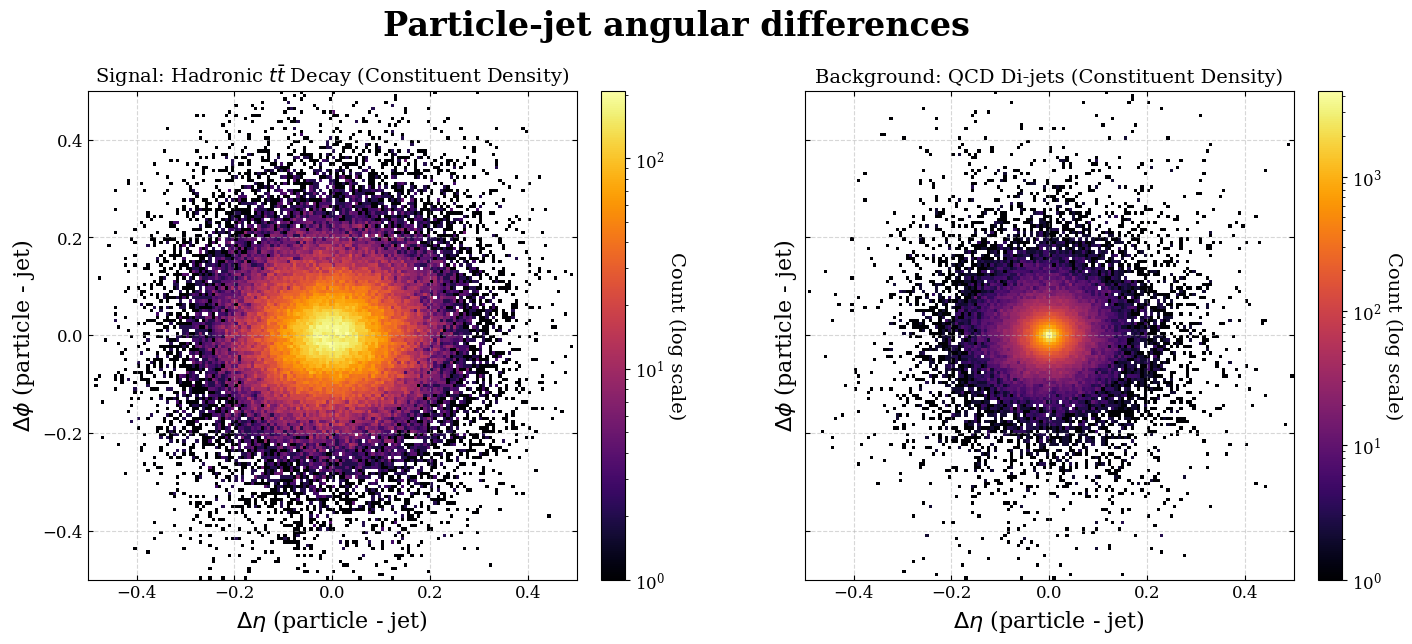

In [57]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "font.family": "serif"
})

# sig vs bkg
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)
img_range = [[-0.5, 0.5], [-0.5, 0.5]]
bin_resolution = 150

# Top quark signal
im0 = axes[0].hist2d(top_data["delta_eta"].to_numpy(), 
                    top_data["delta_phi"].to_numpy(), 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar0 = fig.colorbar(im0[3], ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[0].set_title(r"Signal: Hadronic $t\bar{t}$ Decay (Constituent Density)", fontsize=14)
axes[0].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[0].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

# Background
im1 = axes[1].hist2d(background_data["delta_eta"].to_numpy(), 
                    background_data["delta_phi"].to_numpy(), 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar1 = fig.colorbar(im1[3], ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[1].set_title("Background: QCD Di-jets (Constituent Density)", fontsize=14)
axes[1].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[1].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(img_range[0])
    ax.set_ylim(img_range[1])
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Particle-jet angular differences", fontsize=24, fontweight='bold')
plt.tight_layout()#rect=[0, 0, 1, 0.95])
plt.show()

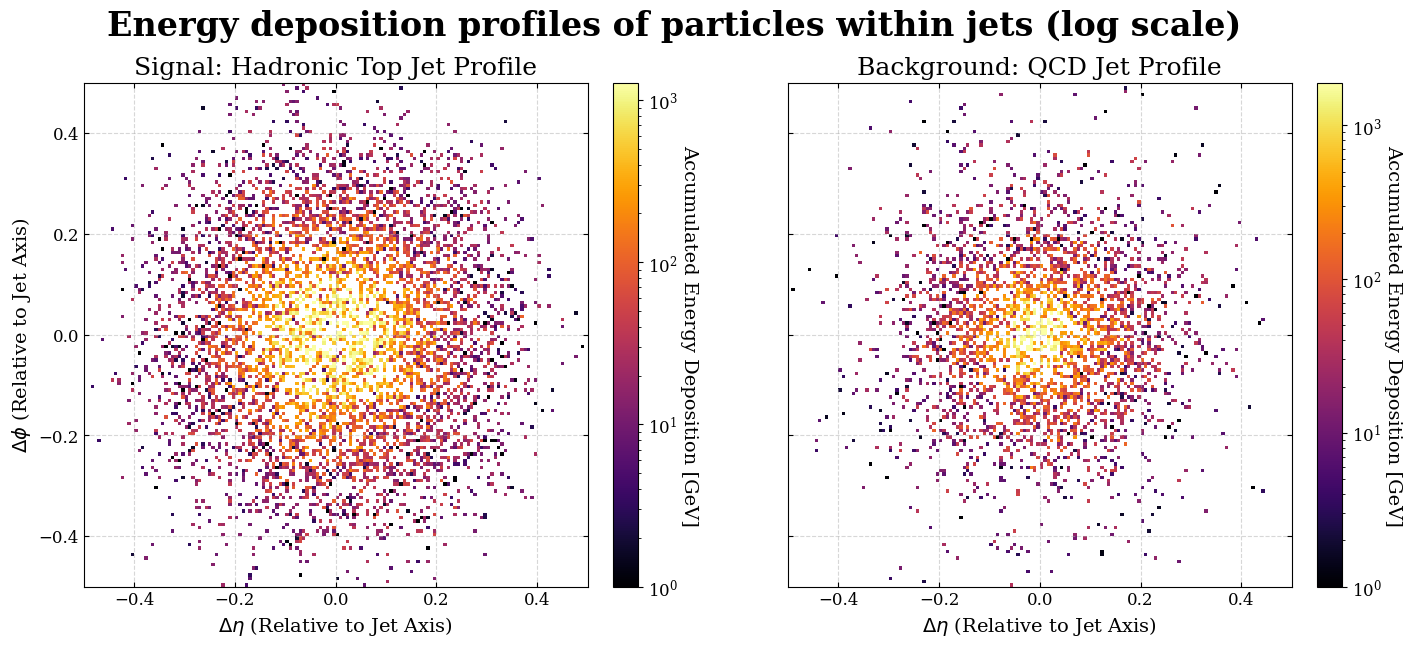

In [ ]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'font.family': 'serif',     # Tipografía serif estándar de revistas como PRD
    'text.usetex': False        # Activar si tienes un compilador LaTeX en tu sistema
})

# Creamos el lienzo: 1 fila, 2 columnas con ejes compartidos
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)

# Rango físico del Jet donde ocurre la desintegración (Anti-kT R=0.8, centrado en 0.5)
img_range = [[-0.5, 0.5], [-0.5, 0.5]]
resolucion_pixeles = 150 

# ================= 1. PERFIL DE ENERGÍA DE LA SEÑAL (TOP QUARK) =================
im0 = axes[0].hist2d(
    top_data["delta_eta"].to_numpy(), 
    top_data["delta_phi"].to_numpy(), 
    weights=top_data["energy"].to_numpy(),  # <--- Aquí está la magia: ponderamos por Energía
    bins=resolucion_pixeles, 
    range=img_range, 
    cmap="inferno",                         # Paleta térmica por excelencia
    norm=LogNorm(vmin=1.0, vmax=top_data["energy"].to_numpy().max())                          # Escala logarítmica para el rango dinámico de energía
)

# Barra de color dedicada para el Top
cbar0 = fig.colorbar(im0[3], ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label('Accumulated Energy Deposition [GeV]', rotation=270, labelpad=15)

axes[0].set_title(r"Signal: Hadronic Top Jet Profile", fontsize=18)
axes[0].set_xlabel(r"$\Delta\eta$ (Relative to Jet Axis)")
axes[0].set_ylabel(r"$\Delta\phi$ (Relative to Jet Axis)")


# ================= 2. PERFIL DE ENERGÍA DEL FONDO (QCD) =================
im1 = axes[1].hist2d(
    background_data["delta_eta"].to_numpy(), 
    background_data["delta_phi"].to_numpy(), 
    weights=background_data["energy"].to_numpy(),  # Ponderamos por Energía
    bins=resolucion_pixeles, 
    range=img_range, 
    cmap="inferno",
    norm=LogNorm(vmin=1.0, vmax=background_data["energy"].to_numpy().max())
)

# Barra de color dedicada para el QCD
cbar1 = fig.colorbar(im1[3], ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label('Accumulated Energy Deposition [GeV]', rotation=270, labelpad=15)

axes[1].set_title("Background: QCD Jet Profile", fontsize=18)
axes[1].set_xlabel(r"$\Delta\eta$ (Relative to Jet Axis)")
axes[1].set_ylabel(r"$\Delta\phi$ (Relative to Jet Axis)")

# ================= AJUSTES DE GEOMETRÍA EXPERIMENTAL =================
for ax in axes:
    ax.set_aspect('equal')              # Relación 1:1 estricta para no deformar el Jet
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.tick_params(direction='in', top=True, right=True)        # Ticks hacia adentro
    ax.grid(True, linestyle='--', alpha=0.5)                      # Cuadrículas para apreciar la textura de la energía

plt.suptitle("Energy deposition profiles of particles within jets (log scale)", fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()